In [1]:
import pandas as pd

# если df уже есть в памяти, эту строку можно пропустить
df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train death rate:", y_train.mean(), "Test death rate:", y_test.mean())

Train: (239, 12) Test: (60, 12)
Train death rate: 0.32217573221757323 Test death rate: 0.31666666666666665


### The dataset was split into training (239 patients) and testing (60 patients) subsets. The mortality rate remains consistent across both sets (~32%), confirming that the stratified split successfully preserved the class distribution. This allows for reliable evaluation of model performance on unseen data.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=500, random_state=42))
])

baseline.fit(X_train, y_train)

proba_lr = baseline.predict_proba(X_test)[:, 1]

roc_lr = roc_auc_score(y_test, proba_lr)
pr_lr  = average_precision_score(y_test, proba_lr)

print("LogReg ROC-AUC:", roc_lr)
print("LogReg PR-AUC:", pr_lr)

LogReg ROC-AUC: 0.8549422336328627
LogReg PR-AUC: 0.7414801186878519


### A logistic regression model was used as a baseline classifier to predict mortality in heart failure patients. Feature scaling was applied to standardize the clinical variables, and class weights were used to address class imbalance in the dataset. Model performance was evaluated using ROC-AUC and PR-AUC metrics. The results indicate that the model is able to reasonably distinguish between survivors and non-survivors, suggesting that the clinical features contain meaningful predictive signals for mortality risk.


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
roc_rf = roc_auc_score(y_test, proba_rf)
pr_rf  = average_precision_score(y_test, proba_rf)

print("RF ROC-AUC:", roc_rf)
print("RF PR-AUC:", pr_rf)

RF ROC-AUC: 0.8979460847240052
RF PR-AUC: 0.801373447010566


### The Random Forest model achieved a ROC-AUC of approximately 0.90 and a PR-AUC of about 0.80, indicating strong predictive performance. These results suggest that the clinical features in the dataset contain meaningful information for distinguishing between survivors and non-survivors. The model is able to effectively identify patients at higher risk of mortality based on their clinical characteristics.


In [6]:
# Model comparison table

import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [roc_lr, roc_rf],
    "PR-AUC": [pr_lr, pr_rf]
})

results.round(3)

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.855,0.741
1,Random Forest,0.898,0.801


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("ROC-AUC mean:", cv_results["test_roc_auc"].mean())
print("ROC-AUC std:", cv_results["test_roc_auc"].std())

print("PR-AUC mean:", cv_results["test_pr_auc"].mean())
print("PR-AUC std:", cv_results["test_pr_auc"].std())

ROC-AUC mean: 0.9044717586649551
ROC-AUC std: 0.022232980220597304
PR-AUC mean: 0.8177087092436558
PR-AUC std: 0.04531479802531758


### The Random Forest model achieved a mean ROC-AUC of 0.904 and a PR-AUC of 0.818 across 5-fold stratified cross-validation. The low standard deviation across folds indicates stable model performance and suggests that the clinical features in the dataset provide strong predictive information for mortality risk in heart failure patients.


In [5]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

time                        0.358322
serum_creatinine            0.161588
ejection_fraction           0.128526
platelets                   0.079182
creatinine_phosphokinase    0.075030
age                         0.070367
serum_sodium                0.062712
high_blood_pressure         0.013416
diabetes                    0.013314
anaemia                     0.013056
smoking                     0.012513
sex                         0.011974
dtype: float64

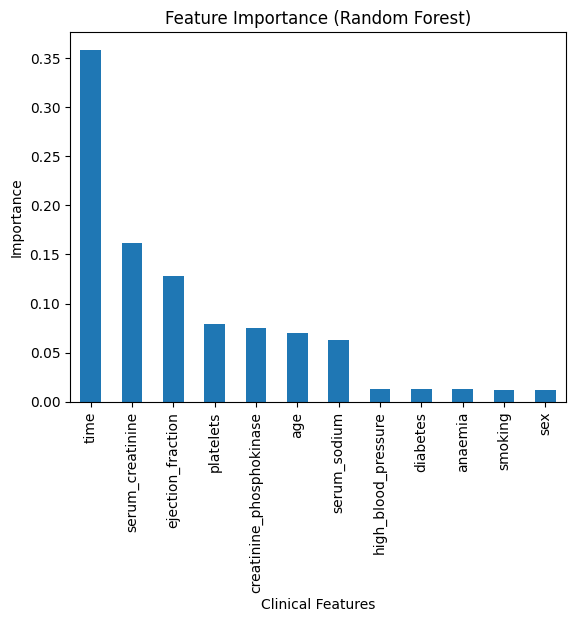

In [6]:
import matplotlib.pyplot as plt

importance.plot(kind="bar")

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Clinical Features")

plt.show()

### Feature importance analysis indicates that variables related to cardiac function (ejection fraction), renal function (serum creatinine), and patient age play a major role in predicting mortality risk. These findings align with established clinical knowledge about heart failure prognosis, where impaired heart function and kidney dysfunction are key determinants of patient outcomes.